# Filter Surveyed Teams

As seen in the `10_llm_extraction_evaluation.ipynb` notebook, the accuracy of LLM-based extraction of task descriptions for each team member varies across teams. One issue is caused by teams that present their data in tables, which the LLM often cannot interpret correctly, leading to hallucinations or missed tasks.

The goal of this notebook is to identify filter criteria that distinguish teams whose attribution text formats are suitable for LLM extraction from those that are not. Surveyed teams with problematic attribution formats (e.g., tables) should be excluded when prompting the model, as they will not have accurately extracted task descriptions.

In [1]:
import pandas as pd
import re
from pathlib import Path
import requests
import time
import json
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Get Surveyed Teams

In [2]:
# From raw_attributions_2022.json, get all teams that have filled out the survey, and save them
# Match raw attributions JSON team names (field "teamName") with the names in survey_tasks.csv (column "team")

survey_tasks_df = pd.read_csv("../data/igem_ties_surveys/2022/survey_tasks.csv")
raw_attributions_df = pd.read_json("../data/attributions/2022_attributions/raw_attributions_2022.json")
validation_teams_df = pd.read_json("../data/attributions/2022_attributions/manual_annotation/5_validation_teams_raw_attributions.json")

ITESO_Guadalajara, NJU-China, Patras_Medicine, Stanford, and Vilnius-Lithuania are in the survey but not in this raw attributions file. They exist in the 5 validation teams extracted manually. HKU_HongKong is not included there because its attributions page did not include tasks for student members (see `8_manually_annotate_team_attributions.ipynb`). For analysis purposes, we will add these 5 validation teams and keep the 14 evaluation teams in the new raw attributions file. However, since their tasks have already been extracted manually, there is no need to give them to the LLM, and they will be removed before prompting for all teams.

In [5]:
# Merge raw attributions with validation teams file that was manually extracted
merged_raw_attributions = pd.concat([raw_attributions_df, validation_teams_df], ignore_index=True)

In [11]:
len(merged_raw_attributions)

316

In [11]:
survey_teams_unique = survey_tasks_df[['team']].drop_duplicates().reset_index(drop=True)

In [12]:
len(survey_teams_unique)

113

In [9]:
survey_teams_unique

,team
0,AFCM-Egypt
1,ASIJ_Tokyo
2,Aachen
3,Aalto-Helsinki
4,Aboa
...,...
108,Wageningen_UR
109,Warwick
110,Waseda_Tokyo
111,Waterloo


In [ ]:
survey_teams_unique['team'].tolist()

['AFCM-Egypt',
 'ASIJ_Tokyo',
 'Aachen',
 'Aalto-Helsinki',
 'Aboa',
 'AshesiGhana',
 'Athens',
 'BUCT',
 'Barcelona_UB',
 'Bio-Brussels',
 'Bonn-Rheinbach',
 'BostonU_HW',
 'Bulgaria',
 'CPU_Nanjing',
 'CSMU_Taiwan',
 'CU-Boulder',
 'Calgary',
 'Cambridge',
 'Chalmers-Gothenburg',
 'Cornell',
 'Costa_Rica',
 'Crete',
 'DeNovoCastrians',
 'Duesseldorf',
 'Duke',
 'Edinburgh-UHAS_Ghana',
 'Estonia_TUIT',
 'Exeter',
 'Freiburg',
 'GO_Paris-Saclay',
 'GastonDay-Shangde',
 'Goettingen',
 'Groningen',
 'HKUST',
 'HKU_HongKong',
 'Heidelberg',
 'ICT-Mumbai',
 'IISER_Bhopal',
 'IISER_Mohali',
 'INSA_Lyon1',
 'ITESO_Guadalajara',
 'Imperial_College_London',
 'Interaction-Data-Lab',
 'Ionis_Paris',
 'JLU_China',
 'KCL_UK',
 'KU_Leuven',
 'Lambert_GA',
 'Leiden',
 'Lethbridge',
 'Lethbridge_HS',
 'Linkoping_Sweden',
 'MIT_MAHE',
 'Michigan',
 'MichiganState',
 'Mingdao',
 'Montpellier',
 'Munich',
 'NCKU_Tainan',
 'NDSU',
 'NJU-China',
 'NTHU_Taiwan',
 'NYCU-Taipei',
 'NYCU_Formosa',
 'Navarra_B

In [ ]:
# Get 2022 attributions wiki URLs for surveyed teams

wiki_urls = pd.read_csv("../data/igem_scrapping_2025/teams_db_downloaded_from_website_4May2025.csv")
wiki_urls_year = wiki_urls.loc[wiki_urls["year"] == 2022].copy()

# Normalize team names
def norm(s):
    return (
        str(s).strip().casefold()
        .replace("\u200b", "")   # zero-width space, just in case
    )

wiki_urls_year["team_norm"] = wiki_urls_year["team"].map(norm)

survey_team_list = (
    survey_teams_unique["team"]
    .dropna()
    .map(norm)
    .drop_duplicates()
    .tolist()
)

matched = wiki_urls_year[wiki_urls_year["team_norm"].isin(survey_team_list)]

wiki_list = matched["wiki"].dropna().drop_duplicates().tolist()

for url in wiki_list:
    print(url + '/attributions')

https://2022.igem.wiki/aachen/attributions
https://2022.igem.wiki/aalto-helsinki/attributions
https://2022.igem.wiki/aboa/attributions
https://2022.igem.wiki/afcm-egypt/attributions
https://2022.igem.wiki/ashesighana/attributions
https://2022.igem.wiki/asij-tokyo/attributions
https://2022.igem.wiki/athens/attributions
https://2022.igem.wiki/barcelona-ub/attributions
https://2022.igem.wiki/bio-brussels/attributions
https://2022.igem.wiki/bonn-rheinbach/attributions
https://2022.igem.wiki/bostonu-hw/attributions
https://2022.igem.wiki/buct/attributions
https://2022.igem.wiki/bulgaria/attributions
https://2022.igem.wiki/calgary/attributions
https://2022.igem.wiki/cambridge/attributions
https://2022.igem.wiki/chalmers-gothenburg/attributions
https://2022.igem.wiki/cornell/attributions
https://2022.igem.wiki/costa-rica/attributions
https://2022.igem.wiki/cpu-nanjing/attributions
https://2022.igem.wiki/crete/attributions
https://2022.igem.wiki/csmu-taiwan/attributions
https://2022.igem.wiki/

In [38]:
merged_raw_attributions 

,teamName,attributionsText
0,Aachen,Project\nDescription Contribution Engineering ...
1,Aalto-Helsinki,Home\nProject\nProject\nDescription\nImplement...
2,Aboa,Home\nAbout us\nTeam members\nAttributions\nCo...
3,AFCM-Egypt,Home\nTeam\nContribution Attributions Team mem...
4,Aix-Marseille,Aix-Marseille\nHome\nTeam\nTeam\nAttributions\...
...,...,...
311,ITESO_Guadalajara,Skip to content\n GitLab\n Explore\n Sign in\n...
312,NJU-China,Team\n # Attribution\n Hi everyone~ We are NJU...
313,Patras_Medicine,Team\nBochalis Eleftherios: Undergraduate Phar...
314,Stanford,Attributions\nWe are extremely grateful for th...


There are 100 unique surveyed teams in 200. We want to keep only those teams in a new raw attributions JSON file, matching by their normalized names.

In [ ]:
# Normalizing team names for matching

# Helper Function to set team names to lower case, remove dashes, remove all blank spaces
def clean_team_name(name):
        return name.lower().replace("-", " ").replace("_", " ").replace(" ", "").strip()

In [ ]:
# Column with cleaned team names 
survey_teams_unique['team_clean'] = survey_teams_unique['team'].apply(clean_team_name)
merged_raw_attributions['team_clean'] = merged_raw_attributions['teamName'].apply(clean_team_name)

In [40]:
# Filter merged_raw_attributions
filtered_raw = merged_raw_attributions[
    merged_raw_attributions['team_clean'].isin(survey_teams_unique['team_clean'])
].copy()

# Find survey teams with no match
matched_teams = set(filtered_raw['team_clean'])
missing_teams = survey_teams_unique[~survey_teams_unique['team_clean'].isin(matched_teams)]

print("\nTeams from survey_teams_unique with no match:")
print(missing_teams['team'])
print(len(missing_teams))


Teams from survey_teams_unique with no match:
34            HKU_HongKong
42    Interaction-Data-Lab
91              UCBerkeley
Name: team, dtype: object
3


Interaction-Data-Lab was just a test survey, and UCBerkeley withdrew from the competition (as seen in `team_meta_full.tsv`). 

In [ ]:
# Save filtered raw attributions JSON
output_path = "../data/attributions/2022_attributions/surveyed_teams_raw_attributions_2022.json"
filtered_raw.to_json(output_path, orient="records", indent=2)

## 2. Get HTML Attributions

Since attributions structured in tables are not clearly represented when saved as a plain text file (as in `raw_attributions_2022.json`), we can instead scrape them directly from the attribution web pages and try using the HTML markup as input for the LLM. We will re-run the LLM for the 14 evaluation teams using their HTML markups instead of the raw text in `9_llm_extract_names_and_task_descriptions.ipynb`, and re-evaluate the results in `10_llm_extraction_evaluation.ipynb`.
A possible solution would be to prompt LLM with HTML markups for teams that contain the "table" HTML element, but prompt it with raw text for teams that do not.

In [5]:
# Get HTML markups

# Example for one team
# request = requests.get("https://2022.igem.wiki/sogang-korea/attributions")
# html_markup = request.text
# print(html_markup)  

# Config
BASE = "https://2022.igem.wiki"
OUTPUT_PATH = "../data/attributions/2022_attributions/html_attributions_2022.json"

TIMEOUT = 100  
SLEEP_BETWEEN = 0.5


# Make teams lowercase for the domain, keep dashes; convert spaces/underscores to dashes 
def convert_team_name(name):
    s = name.strip().lower()
    s = s.replace("_", "-")    
    return s

In [ ]:
# Loop for all teams

results = []
skipped = []

teams = (
    merged_raw_attributions["teamName"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

for team in teams:
    converted_team_name = convert_team_name(team)
    url = f"{BASE}/{converted_team_name}/attributions" 
    fallback_url = f"{BASE}/{converted_team_name}/team/attribution/"

    try:
        resp = requests.get(url, timeout=TIMEOUT, headers={"User-Agent": "Mozilla/5.0"})
        if resp.status_code == 200 and resp.text.strip():
            results.append({
                "teamName": team,
                "attributionsText": resp.text,
            })
        elif resp.status_code == 404:
            # Try fallback URL
            resp_fallback = requests.get(fallback_url, timeout=TIMEOUT, headers={"User-Agent": "Mozilla/5.0"})
            if resp_fallback.status_code == 200 and resp_fallback.text.strip():
                results.append({
                    "teamName": team,
                    "attributionsText": resp_fallback.text,
                })
            else:
                print(f"Skipped {converted_team_name} – HTTP {resp_fallback.status_code}")
                skipped.append(team)
    except Exception as e:
        print(f"Error fetching {team}: {e}")
        skipped.append(team)

    time.sleep(SLEEP_BETWEEN)

# Save successful HTML results
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Saved {len(results)} HTML entries to {OUTPUT_PATH}")

In [24]:
print(skipped)

['CAU_China', 'Costa_Rica', 'SUSTech_EMB', 'TecCEM', 'Stanford']


In [11]:
# Example for one team
request = requests.get("https://2022.igem.wiki/cau-china/attributions")
print(request.status_code)
print(request.text)  

404
<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <link rel="icon" type="image/svg+xml" href="https://static.igem.wiki/teams/4192/wiki/web0iegm0icon.png" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>Team:CAU China - 2022.igem.org</title>
    <!-- <script src="https://2021.igem.org/common/MathJax-2.5-latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML"></script>
    <script type="text/x-mathjax-config">
      MathJax.Hub.Config({tex2jax: {inlineMath: [['$','$'], ['\\(','\\)']]}});
    </script> -->
    <script type="module" crossorigin src="/cau-china/assets/main.795b72b1.js"></script>
    <link rel="stylesheet" href="/cau-china/assets/404.54103cc7.css">
  </head>
  <body>
    <div id="app"></div>
    
    <!-- <span>
      $$
      f(x, y) = 3(1-x)^2e^{-x^2-(y+1)^2}-10(\frac{1}{5}x-x^3-y^5)e^{-x^2-y^2}-\frac{1}{3}e^{-(x+1)^2-y^2}
      $$
      
      $$
      \alpha \beta \delta \sigma \phi
      $$
      </span> --

**Note**: There is one team whose raw attributions are an empty string and their `attributions.txt` file is empty as well. We should check if there are any other empty raw attributions and extract them from the team's wiki. We will extract text instead of html elements for this team, and append it to `raw_attributions_2022.json` as well as write out team's `attributions.txt` file.

In [ ]:
raw_attributions_df[raw_attributions_df['attributionsText']==""]

,teamName,attributionsText
122,JLU_China,


In [17]:
import nest_asyncio
nest_asyncio.apply()

from requests_html import AsyncHTMLSession
import asyncio
import json

missing_team_attributions_name = "JLU_China"
raw_attributions_path = "../data/attributions/2022_attributions/raw_attributions_2022.json"
converted_team_name = convert_team_name(missing_team_attributions_name)
missing_team_attributions_file_path = (f"../data/igem_team_websites/2022/{converted_team_name}/attributions.txt")

asession = AsyncHTMLSession()

# To fetch attributions of team
async def fetch_page():
    r = await asession.get(f"https://2022.igem.wiki/{converted_team_name}/attributions/")
    await r.html.arender(timeout=30, sleep=2)

    result = r.html.text.strip()  # extracted text
    await asession.close()
    return result

# To fetch and update missing team attribution in raw_attributions_2022.json and write to attributions.txt
async def main():
    result = await fetch_page()

    with open(raw_attributions_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for entry in data:
        if entry["teamName"] == missing_team_attributions_name:
            entry["attributionsText"] = result
            break
    else:
        raise ValueError(f"Team '{missing_team_attributions_name}' not found in JSON")

    with open(raw_attributions_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    with open(missing_team_attributions_file_path, "w", encoding="utf-8") as f:
        f.write(result)

    print("Done: JSON updated and attribution file written.")


asyncio.run(main())

Done: JSON updated and attribution file written.


The issue with 5 skipped teams is that their page source calls back a Javascript file, as seen in the output of the previous cell. We can fetch this HTML markup but it is not useful as it does not contain actual attributions text. These teams are skipped in the loop because the request returns a 404.

To collect the actual html markup that contains attribution texts, we can import HTMLSession from requests_html. However, this works only in a Python file and not a Jupyter notebook since Jupyter already runs an event loop that colides with the HTMLSession. AsyncHTMLSession works in a Jupyter notebook, but it can only return the initial HTML shell or the attributions text without the HTML markup (which we need for distinguishing teams that have attributions structured in tables). Therefore, we will fetch the correct HTMLs for these 5 teams in a helper Python file and append them to `html_attributions_2022.json`. See `11_html_attributions_helper.py`.

## 3. Extract Teams with table HTML elements

In [ ]:
html_attributions_data = pd.read_json("../data/attributions/2022_attributions/html_attributions_2022.json")
# html_attributions_data = pd.read_json("../data/attributions/2022_attributions/html_attributions_2022_second_version.json")

In [28]:
html_attributions_data

,teamName,attributionsText
0,Aachen,"<html lang=""en""><head><meta charset=""UTF-8""><m..."
1,Aalto-Helsinki,"<!doctype html>\n<html lang=""en"">\n\n<head>\n ..."
2,Aboa,"<!DOCTYPE html>\n\n<html lang=""en"">\n <head>\..."
3,AFCM-Egypt,"<!DOCTYPE html>\n<html lang=""en"">\n\n<head>\n ..."
4,Aix-Marseille,"<!doctype html>\n<html lang=""en"">\n <head>\n ..."
...,...,...
311,CAU_China,"<!DOCTYPE html><html lang=""en""><head>\n <me..."
312,Costa_Rica,"<!DOCTYPE html><html lang=""en""><head>\n <meta..."
313,SUSTech_EMB,"<!DOCTYPE html><html lang=""en""><head><meta cha..."
314,TecCEM,"<!DOCTYPE html><html lang=""en""><head><meta cha..."


In [5]:
# Extract Teams with at least one table HTML element with BeautifulSoup for easier parsing

teams_with_table = []

for _, row in html_attributions_data.iterrows():
    html = row["attributionsText"]
    soup = BeautifulSoup(html, "html.parser")

    if soup.find("table"):
        teams_with_table.append(row["teamName"])

In [6]:
teams_with_table

['Aboa',
 'ASIJ_Tokyo',
 'BNU-China',
 'CCA_San_Diego',
 'CPU_CHINA',
 'CSU_CHINA',
 'DNHS_SanDiego_CA',
 'ECNUAS',
 'ELTE',
 'GA_State_SW_Jiaotong',
 'GEMS_Taiwan',
 'GO_Paris-Saclay',
 'GreatBay_SCIE',
 'Groningen',
 'Heidelberg',
 'IISER-Pune-India',
 'IISER-Pune2_India',
 'KCIS_Xiugang_Taipei',
 'KU_Leuven',
 'KUAS_Korea',
 'Lambert_GA',
 'Leiden',
 'Linkoping_Sweden',
 'LINKS_China',
 'Lund',
 'MIT',
 'Nanjing_HS',
 'Nanjing_NFLS',
 'NCKU_Tainan',
 'NEU_CHINA',
 'NYC_Empire_State',
 'NYU_Abu_Dhabi',
 'Paris_Bettencourt',
 'SCU-China',
 'SCUT-China',
 'ShanghaiTech_China',
 'Sogang_Korea',
 'SUNY_Oneonta',
 'SZ-SHD',
 'SZU-China',
 'TAMU',
 'TAU_Israel',
 'TheKingsSchool_AU_HS',
 'Thessaloniki',
 'Tianjin',
 'TUDelft',
 'Tuebingen',
 'UBC-Okanagan',
 'UCAS-China',
 'Uni-Hamburg',
 'UNSW_Australia',
 'UTokyo',
 'Wageningen_UR',
 'Worldshaper-HZ',
 'Worldshaper-Nanjing',
 'Worldshaper-Shanghai',
 'WWU_Muenster',
 'ZJU-China',
 'NJU-China',
 'Vilnius-Lithuania']

In [7]:
len(teams_with_table)

60

In [15]:
survey_teams_list =  survey_teams_unique['team'].tolist()

In [17]:
common_teams = list(set(teams_with_table) & set(survey_teams_list))
common_teams

['Groningen',
 'Aboa',
 'Tuebingen',
 'SUNY_Oneonta',
 'Lambert_GA',
 'NCKU_Tainan',
 'Vilnius-Lithuania',
 'ASIJ_Tokyo',
 'Paris_Bettencourt',
 'Sogang_Korea',
 'WWU_Muenster',
 'NJU-China',
 'GO_Paris-Saclay',
 'UTokyo',
 'Heidelberg',
 'TAU_Israel',
 'KU_Leuven',
 'Linkoping_Sweden',
 'Leiden',
 'Wageningen_UR',
 'Uni-Hamburg']

In [19]:
len(common_teams)

21

There are 60 teams with table elements, out of which 21 are also in the survey. We might want to prompt LLM for these teams with their HTML attributions, while we prompt for the other ones with their raw attributions texts (shorter and clearer prompts). We will evaluate different types of prompting in `10_llm_extraction_evaluation.ipynb`.

## 4. Distribution of Number of Characters

When comparing the lengths of HTML markups fetched with `requests`, it was noticed that HTMLs for some teams still did not contain attributions texts, but a call to a Javascript file instead. For this reason, HTML markups were then fetched in the `11_html_attributions_helper` Python file for all teams with `HTMLSession`. `HTMLSession` fetches the entire HTML markup and executes all JavaScript on the page. The fetched markups are usually longer than the ones fetched with `requests`. 

In [14]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (12, 8),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

In [21]:
html_attributions_data = pd.read_json("../data/attributions/2022_attributions/html_attributions_2022.json")
html_attributions_second_version = pd.read_json("../data/attributions/2022_attributions/html_attributions_2022_second_version.json")

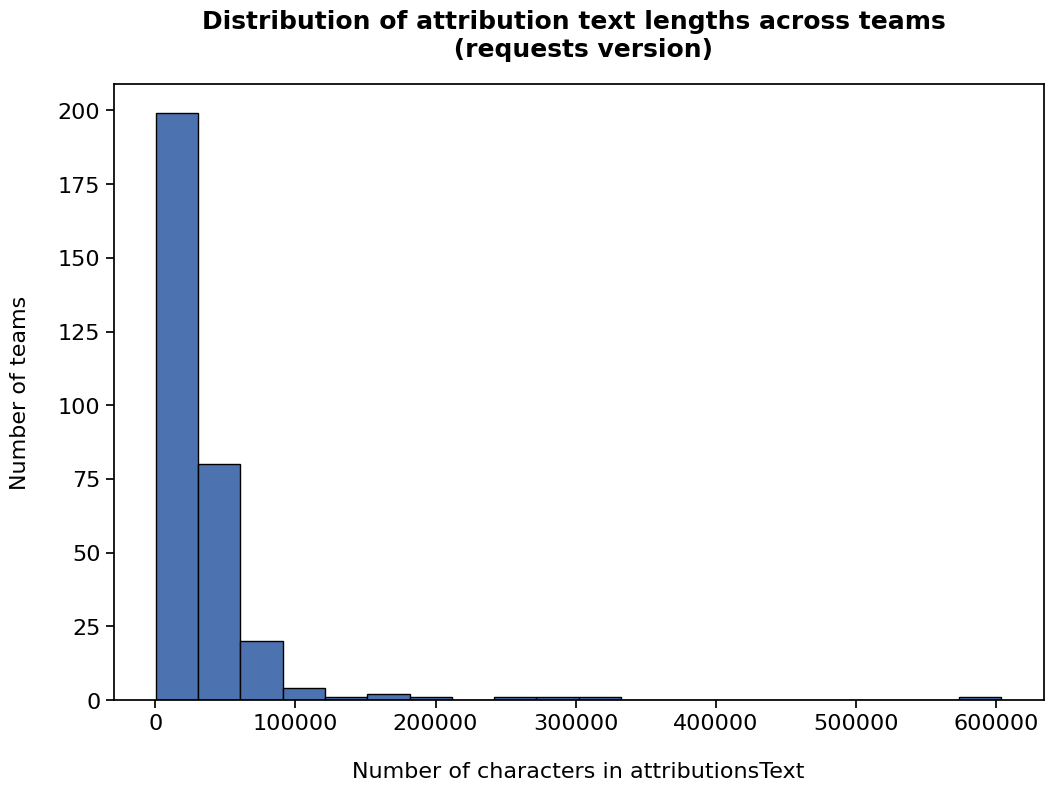

In [19]:
# First version HTML attributions plot (fetched with requests)

# Create a new column with character counts
html_attributions_data['char_count'] = html_attributions_data['attributionsText'].str.len()

plt.hist(html_attributions_data['char_count'], bins=20, edgecolor='black')
plt.xlabel('Number of characters in attributionsText')
plt.ylabel('Number of teams')
plt.title('Distribution of attribution text lengths across teams \n (requests version)')
plt.show()


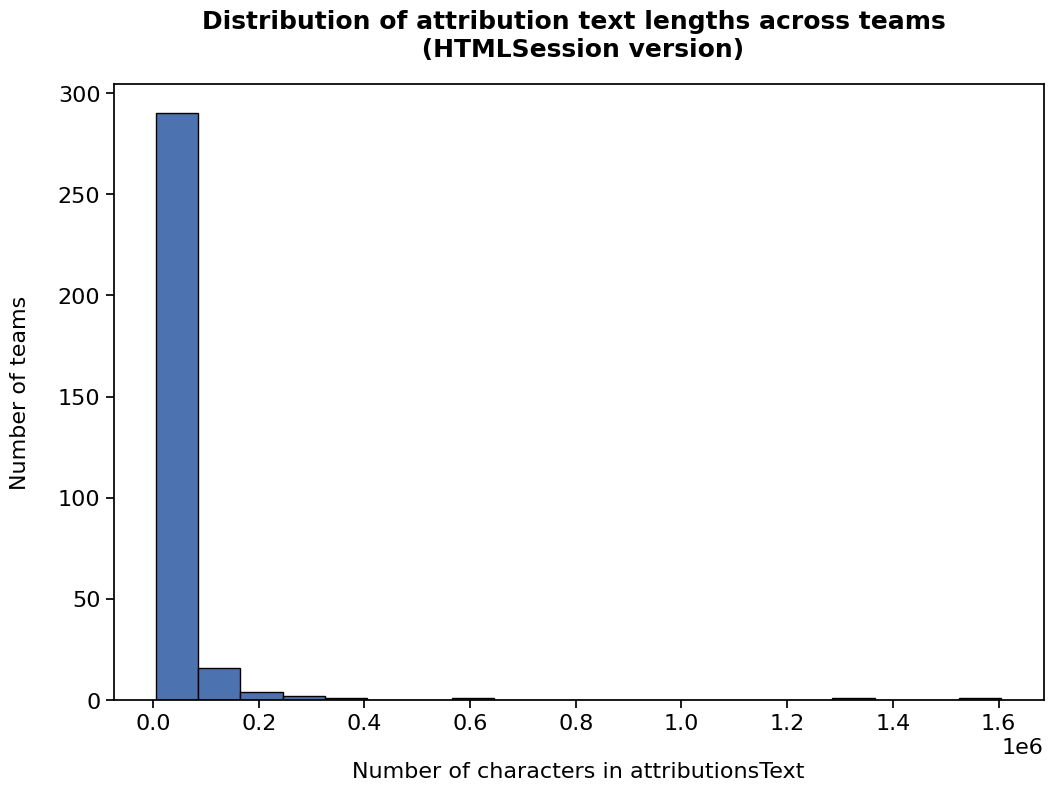

In [22]:
# Second version HTML attributions plot (fetched with HTML sessions, usually longer HTML Markups)

html_attributions_second_version['char_count'] = html_attributions_second_version['attributionsText'].str.len()

plt.hist(html_attributions_second_version['char_count'], bins=20, edgecolor='black')
plt.xlabel('Number of characters in attributionsText')
plt.ylabel('Number of teams')
plt.title('Distribution of attribution text lengths across teams \n (HTMLSession version)')
plt.show()

In [ ]:
# Stats table - 1st version

html_attributions_data['char_count'].describe()

count       316.000000
mean      34594.971519
std       47194.405458
min         522.000000
25%       14921.250000
50%       25707.000000
75%       38191.750000
max      603621.000000
Name: char_count, dtype: float64

In [27]:
# Stats table - 2nd version

html_attributions_second_version['char_count'].describe()

count    3.160000e+02
mean     4.927511e+04
std      1.234228e+05
min      5.180000e+03
25%      1.690475e+04
50%      2.822300e+04
75%      4.328750e+04
max      1.605315e+06
Name: char_count, dtype: float64

In [ ]:
# Outliers - 1st version
Q1 = html_attributions_data['char_count'].quantile(0.25)
Q3 = html_attributions_data['char_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = html_attributions_data[
    (html_attributions_data['char_count'] < lower_bound) | 
    (html_attributions_data['char_count'] > upper_bound)
]

outlier_teams = outliers[['teamName', 'char_count']].sort_values('char_count')
print(outlier_teams)

              teamName  char_count
276               USTC       74826
177        NYCU-Taipei       77021
247       UBC-Okanagan       77568
218             SZ-SHD       81721
223      Tec-Chihuahua       82921
166         NJMU-China       84470
47            CU_Egypt       85376
9                  ASU       89289
109  IISER-Pune2_India       89716
261           UM_Macau       91402
290     Worldshaper-HZ       91583
108   IISER-Pune-India       94269
308          NJU-China      109576
253               UCSC      127558
310  Vilnius-Lithuania      167742
164          NEU_CHINA      168138
239  Toulouse_INSA-UPS      196547
25          BostonU_HW      244680
309    Patras_Medicine      276948
154             Munich      312420
217   Sydney_Australia      603621


In [26]:
# Outliers - 2nd version
Q1 = html_attributions_second_version['char_count'].quantile(0.25)
Q3 = html_attributions_second_version['char_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = html_attributions_second_version[
    (html_attributions_second_version['char_count'] < lower_bound) | 
    (html_attributions_second_version['char_count'] > upper_bound)
]

outlier_teams = outliers[['teamName', 'char_count']].sort_values('char_count')
print(outlier_teams)

              teamName  char_count
111  IISER-Pune2_India       86072
9                  ASU       86973
290           Waterloo       90345
294     Worldshaper-HZ       90918
265           UM_Macau       91989
168         NJMU-China       92316
110   IISER-Pune-India       94464
226      Tec-Chihuahua       95497
312          NJU-China      109576
257               UCSC      125335
132             Leiden      134950
288       Waseda_Tokyo      137569
214        Stony_Brook      137773
303         XJTU-China      140765
147             MiamiU      157642
243  Toulouse_INSA-UPS      159677
166          NEU_CHINA      165218
315  Vilnius-Lithuania      173534
197          SCU-China      173768
7          AshesiGhana      221918
25          BostonU_HW      246136
313    Patras_Medicine      277886
156             Munich      327595
220   Sydney_Australia      610981
310         ZJUT-China     1290918
128          KU_Leuven     1605315


In [ ]:
# Filter teams with short attributions
short_text_teams = html_attributions_data[html_attributions_data['char_count'] < 5000]

print(short_text_teams[['teamName', 'char_count']].sort_values('char_count'))

print(short_text_teams['teamName'].tolist())

           teamName  char_count
242      TU_Dresden         522
225          TecCCM         590
286        Waterloo         701
252     UCopenhagen         705
260          ULaval         721
306      ZJUT-China         994
38   CityU_HongKong        1075
153  MSP-Maastricht        1221
235    TJUSLS_China        1341
284    Waseda_Tokyo        3800
['CityU_HongKong', 'MSP-Maastricht', 'TecCCM', 'TJUSLS_China', 'TU_Dresden', 'UCopenhagen', 'ULaval', 'Waseda_Tokyo', 'Waterloo', 'ZJUT-China']


## 5. Manual Annotation of Attributions Structures

Considering the difficulty of finding teams whose attributions are listed on images on their Wiki pages, as the number of chatracters can't always be reliable, we manually checked each Wiki page and noted the attributions structures (check `"../data/attributions/2022_attributions/manual_annotation/wiki_attributions_structures_2022_teams.tsv"`).

The teams either have normal, textual attriburions, and for such teams, the LLM should be prompted with their raw attributions texts. Other teams have attributions in tables that are sometimes readable (they contain text), sometimes not (contain symbols like X). For those teams that are not readable in Rathin's extraxted raw attribution texts, the LLM will be prompted with the HTMLs of the Wiki pages. Lastly, 15 surveyed teams have their attributions in images, and so we do not complicate the LLM extraction task, we will annotate these teams manually. We will only annotate their members that filled out the survey.

In [6]:
# Three types of teams: excluded because of image attributions (manual), table-prompted, text-prompted
attributions_structures = pd.read_csv("../data/attributions/2022_attributions/manual_annotation/wiki_attributions_structures_2022_teams.tsv", sep="\t")

no_attributions_teams = attributions_structures['Team'][attributions_structures['Attributions Structure'].isna()]
image_teams = attributions_structures['Team'][attributions_structures['Should be done manually'] == "yes"]
table_teams = attributions_structures['Team'][attributions_structures['Should be prompted with html'] == "yes"]
text_teams = attributions_structures['Team'][attributions_structures['Should be prompted with text'] == "yes"]

In [8]:
len(no_attributions_teams), len(image_teams), len(table_teams), len(text_teams)

(2, 13, 6, 73)

In [19]:
image_teams

4              AshesiGhana
7             Barcelona_UB
11                    BUCT
12                Bulgaria
13                 Calgary
25    Edinburgh-UHAS_Ghana
26            Estonia_TUIT
32               Groningen
55             Montpellier
70            Shym_BIL_NIS
89                     UAM
91                     UCL
95              UMA_MALAGA
Name: Team, dtype: object

In [10]:
# Get rosters for excluded teams - copy paste to manual annotation file for "Image" teams - but get only surveyed members (can be done in notebook 14)

df_roster = pd.read_table("../data/attributions/2022_attributions/team_rosters_2022.tsv")

print(
    df_roster.loc[df_roster["Team"].isin(image_teams), ["FullName", "Team"]]
        .to_csv(sep="\t", index=False)
)

FullName	Team
Tamisha Dzifa Akuyor Segbefia	AshesiGhana
Elena Rosca	AshesiGhana
Michael Boateng	AshesiGhana
Trish Anesu Maduche	AshesiGhana
Betty Essien	AshesiGhana
Edith Boakye	AshesiGhana
Elijah Boateng	AshesiGhana
Gideon Donkor Bonsu	AshesiGhana
Leeroy Takudzwa Magora	AshesiGhana
Rosemond Nyatefe Tawiah	AshesiGhana
Sandra Waterwood Acquah	AshesiGhana
Vera Bordah	AshesiGhana
Haosheng Liu	BUCT
Yimiao Lin	BUCT
Xinxiao Sun	BUCT
Jia Wang	BUCT
Xiaolin Shen	BUCT
Zhengjun Li	BUCT
Jiani Man	BUCT
Sharon Zou	BUCT
Shuo Zhang	BUCT
Cai xinyi	BUCT
Chen Siwei	BUCT
Dai jia	BUCT
Hongxu Zhou	BUCT
Jihua Wei	BUCT
Kexin Nie	BUCT
Wang yutong	BUCT
Wenjun Xie	BUCT
Xia Wei	BUCT
Yazhao Liu	BUCT
Yujie Zhang	BUCT
Yutong Su	BUCT
Yuxuan Huo	BUCT
Zhang Shiyu	BUCT
Zheng Ma	BUCT
Zheng Yang	BUCT
Ziting Xu	BUCT
Ziyu Zhou	BUCT
Zongyu Yao	BUCT
Marcelo Lima Ribeiro	Barcelona_UB
Nuria Profitos	Barcelona_UB
Manuel Reina	Barcelona_UB
Gael Roue	Barcelona_UB
Olalla Ramirez	Barcelona_UB
Pau Mar�n Escudero	Barcelona_UB
Alejandr